In [1]:
import torch.nn as nn
import torch
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.models as models
from torch.utils.data import DataLoader

In [67]:
class RecognitionModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.backbone = backbone
        self.backbone.classifier = nn.Identity() # ConvNext, Densenet, EfficientNet
        # self.backbone.fc = nn.Identity() # Resnet
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.fc1 = nn.Linear(768, 1) # ConvNext-Tiny
        # self.fc1 = nn.Linear(2048, 1) # Resnet50
        # self.fc1 = nn.Linear(1024, 1) # Densenet121
        # self.fc1 = nn.Linear(1792, 1) # EfficientNetB4
        

        

    def forward(self, x1, x2):
        f1 = self.backbone(x1)
        f1 = torch.flatten(f1, 1)
        f2 = self.backbone(x2)
        f2 = torch.flatten(f2, 1)
        feat = torch.abs(f1 - f2)  # ใช้ความต่างเป็น feature
        out = torch.sigmoid(self.fc1(feat))
        return out


In [28]:
import torch
import time
import os
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt # (ต้องใช้สำหรับ plot_training_history)

# ⭐️ 1. สร้างฟังก์ชันผู้ช่วย (Helper Function)
def _run_epoch(loader, model, criterion, device, is_training=False, optimizer=None):
    """
    ฟังก์ชันภายในสำหรับรัน 1 epoch (ไม่ว่าจะ train หรือ val)
    จะคืนค่า metrics ทั้งหมดที่คำนวณได้
    """
    # ⭐️ 2. ตั้งค่าโหมด model.train() หรือ model.eval()
    if is_training:
        model.train()
        if optimizer is None:
            raise ValueError("Optimizer must be provided during training")
    else:
        model.eval()

    # ⭐️ 3. ย้ายตัวแปรทั้งหมดมาไว้ที่นี่
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    total_latency_time = 0.0

    # ⭐️ 4. ลูปที่เหมือนกัน
    for img1, img2, labels in loader:
        img1, img2, labels_device = img1.to(device), img2.to(device), labels.to(device)
        
        # ⭐️ 5. จัดการ Optimizer และ Gradient (ถ้าเป็น training)
        if is_training:
            optimizer.zero_grad()
        
        # ⭐️ 6. ตรรกะ Forward pass และ Latency (เหมือนเดิม)
        start_time = time.perf_counter()
        outputs = model(img1, img2).squeeze()
        total_latency_time += (time.perf_counter() - start_time)
        
        loss = criterion(outputs, labels_device)
        
        # ⭐️ 7. จัดการ Backward pass (ถ้าเป็น training)
        if is_training:
            loss.backward()
            optimizer.step()
            
        # ⭐️ 8. ตรรกะการรวบรวม Metrics (เหมือนเดิม)
        running_loss += loss.item() * labels_device.size(0)
        preds = (outputs >= 0.5).float()
        correct += (preds == labels_device).sum().item()
        total += labels_device.size(0)
        
        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.cpu()) # ใช้ labels original (อยู่บน CPU)

    # ⭐️ 9. การคำนวณสรุป (ย้ายมาที่นี่)
    if total == 0:
        # ป้องกันการหารด้วยศูนย์ ถ้า loader ว่างเปล่า
        return 0, 0, 0, 0

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_latency = total_latency_time / total
    
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    epoch_f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return epoch_loss, epoch_acc, epoch_f1, epoch_latency


# ⭐️ 10. ฟังก์ชันหลัก (Train Loop) ที่สะอาดขึ้น
def train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=10, save_path="best_model.pth"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    history = {
        "train_loss": [], "val_loss": [], 
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
        "train_latency": [], "val_latency": []
    }
    
    best_val_acc = 0.0
    save_path = os.path.join("runs", "recognition", save_path)

    for epoch in range(epochs):
        
        # ---------- TRAIN ----------
        # ⭐️ 11. เรียกใช้ _run_epoch (โหมด training)
        train_loss, train_acc, train_f1, train_latency = _run_epoch(
            train_loader, model, criterion, device, is_training=True, optimizer=optimizer
        )
        
        # ---------- VALIDATION ----------
        # ⭐️ 12. เรียกใช้ _run_epoch (โหมด val) ภายใน torch.no_grad()
        with torch.no_grad():
            val_loss, val_acc, val_f1, val_latency = _run_epoch(
                val_loader, model, criterion, device, is_training=False
            )

        # ---------- SCHEDULER (เหมือนเดิม) ----------
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        # ---------- SAVE HISTORY (เหมือนเดิม แต่กระชับขึ้น) ----------
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["train_latency"].append(train_latency)
        
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_latency"].append(val_latency)

        # ---------- PRINT (เหมือนเดิม) ----------
        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"T Loss: {train_loss:.4f}, T Acc: {train_acc:.4f}, T F1: {train_f1:.4f} | "
              f"V Loss: {val_loss:.4f}, V Acc: {val_acc:.4f}, V F1: {val_f1:.4f} | "
              f"V Latency: {val_latency*1000:.2f} ms/sample")
        
        # ---------- SAVE BEST MODEL (เหมือนเดิม) ----------
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print(f"🎉 New best model saved to {save_path} (Val Acc: {best_val_acc:.4f})")

    return history

In [4]:
import os
import random
from itertools import combinations, product
from sklearn.model_selection import train_test_split

def make_all_pairs(dataset_dir, val_ratio=0.2, random_seed=42):
    random.seed(random_seed)

    # --- เตรียมโฟลเดอร์หมา/แมว ---
    dog_dir = os.path.join(dataset_dir, "yo_Dogs")
    cat_dir = os.path.join(dataset_dir, "yo_Cats")
    all_folders = []

    for base_dir in [dog_dir, cat_dir]:
        folders = [os.path.join(base_dir, d) for d in os.listdir(base_dir)
                   if os.path.isdir(os.path.join(base_dir, d))]
        all_folders += folders

    # --- เก็บไฟล์รูปของแต่ละ class ---
    class_to_images = {}
    for folder in all_folders:
        nose_folder = os.path.join(folder, "Nose")
        if os.path.exists(nose_folder):
            images = [os.path.join(nose_folder, f) for f in os.listdir(nose_folder)
                      if f.lower().endswith((".jpg", ".png", ".jpeg"))]
            if images:
                class_to_images[nose_folder] = images

    # --- แบ่ง train / val บน level ของรูป ---
    train_classes, val_classes = {}, {}
    for cls, images in class_to_images.items():
        train_imgs, val_imgs = train_test_split(images, test_size=val_ratio, random_state=random_seed)
        if train_imgs:
            train_classes[cls] = train_imgs
        if val_imgs:
            val_classes[cls] = val_imgs

    # --- ฟังก์ชันสร้าง pairs ---
    def create_pairs(class_dict):
        pairs = []
        classes = list(class_dict.keys())
        # Positive pairs
        for cls, images in class_dict.items():
            combs = list(combinations(images, 2))
            # จำกัดจำนวนสูงสุด
            for img1, img2 in combs:
                pairs.append((img1, img2, 1))
        # Negative pairs (balance: 1 negative per positive)
        num_positive = len(pairs)
        neg_pairs = []
        while len(neg_pairs) < num_positive:
            cls1, cls2 = random.sample(classes, 2)
            img1 = random.choice(class_dict[cls1])
            img2 = random.choice(class_dict[cls2])
            neg_pairs.append((img1, img2, 0))
        pairs += neg_pairs
        random.shuffle(pairs)
        return pairs

    train_pairs = create_pairs(train_classes)
    val_pairs = create_pairs(val_classes)

    return train_pairs, val_pairs



# ===============================
# Example run
# ===============================
dataset_dir = "datasets\\dataset_same_dog_and_cat"
train_pairs, test_pairs = make_all_pairs(dataset_dir)

In [71]:
import os
import random
from sklearn.model_selection import train_test_split
from contextlib import redirect_stderr, redirect_stdout
import io

def make_pairs(dataset_dir, num_pairs=1000):
    """
    สร้างคู่รูปภาพ (positive และ negative) จากโครงสร้างโฟลเดอร์
    .../Species/Breed/Individual_Name/Images
    
    ปรับปรุง:
    - Positive (label 1): รูป 2 รูป จาก "สัตว์ตัวเดียวกัน"
    - Negative (label 0): รูป 2 รูป จาก "สัตว์คนละตัว" แต่ "สายพันธุ์เดียวกัน"
    """
    pairs = []
    
    # dùng đểเก็บรูปของแต่ละตัว (key: path/to/individual, value: [img1, img2])
    class_to_images = {} 
    
    # dùng đểเก็บ "ตัว" ทั้งหมดที่อยู่ใน "สายพันธุ์" นั้นๆ
    # (key: path/to/breed, value: [path/to/individual1, path/to/individual2])
    breed_to_individuals = {}

    # --- 1. สแกนโฟลเดอร์และเก็บข้อมูล ---
    for species in ["Dog", "Cat"]:
        species_dir = os.path.join(dataset_dir, species)
        if not os.path.isdir(species_dir):
            continue
            
        breed_folders = [os.path.join(species_dir, b) for b in os.listdir(species_dir) 
                         if os.path.isdir(os.path.join(species_dir, b))]
        
        for breed_folder in breed_folders:
            # สร้าง list ของสัตว์แต่ละตัวในสายพันธุ์นี้
            individuals_in_this_breed = []
            
            individual_folders = [os.path.join(breed_folder, i) for i in os.listdir(breed_folder)
                                  if os.path.isdir(os.path.join(breed_folder, i))]

            for individual_folder in individual_folders:
                images = []
                for f in os.listdir(individual_folder):
                    if f.lower().endswith((".jpg", ".png", ".jpeg")):
                        images.append(os.path.join(individual_folder, f))
                
                # สัตว์ตัวนั้นต้องมีอย่างน้อย 2 รูป (เพื่อสร้าง Positive pair)
                if len(images) > 1:
                    class_to_images[individual_folder] = images
                    individuals_in_this_breed.append(individual_folder)
            
            # สายพันธุ์นั้นต้องมีสัตว์อย่างน้อย 2 ตัว (เพื่อสร้าง Negative pair)
            if len(individuals_in_this_breed) > 1:
                breed_to_individuals[breed_folder] = individuals_in_this_breed

    # --- 2. ตรวจสอบข้อมูลที่ได้ ---
    all_individual_classes = list(class_to_images.keys())
    valid_breeds_for_negatives = list(breed_to_individuals.keys())
    
    if not all_individual_classes:
        print("Error: ไม่พบสัตว์ตัวใดเลยที่มีรูปมากกว่า 1 รูป (สร้าง Positive pair ไม่ได้)")
        return []
        
    if not valid_breeds_for_negatives:
        print("Error: ไม่พบสายพันธุ์ใดเลยที่มีสัตว์มากกว่า 1 ตัว (สร้าง Negative pair ไม่ได้)")
        return []

    print(f"พบสัตว์ทั้งหมด {len(all_individual_classes)} ตัว (สำหรับ Positive pairs)")
    print(f"พบ {len(valid_breeds_for_negatives)} สายพันธุ์ (สำหรับ Hard Negative pairs)")

    # --- 3. สร้าง Pairs ---
    for _ in range(num_pairs):
        # สุ่ม 50% ว่าจะเป็น positive หรือ negative
        if random.random() < 0.5:
            # ---------- Positive pair (label 1) ----------
            # (เหมือนเดิม: สุ่มสัตว์ 1 ตัว -> สุ่ม 2 รูปจากตัวนั้น)
            cls = random.choice(all_individual_classes)
            try:
                imgs = random.sample(class_to_images[cls], 2) 
                pairs.append((imgs[0], imgs[1], 1))
            except ValueError:
                continue
                
        else:
            # ---------- Negative pair (label 0) (แบบใหม่) ----------
            try:
                # 1. สุ่ม "สายพันธุ์" ที่มีสัตว์อย่างน้อย 2 ตัว
                random_breed_path = random.choice(valid_breeds_for_negatives)
                
                # 2. สุ่ม "สัตว์ 2 ตัว" (cls1, cls2) จากสายพันธุ์นั้น
                individuals_in_breed = breed_to_individuals[random_breed_path]
                cls1, cls2 = random.sample(individuals_in_breed, 2)
                
                # 3. สุ่มรูป 1 ใบจากสัตว์แต่ละตัว
                img1 = random.choice(class_to_images[cls1])
                img2 = random.choice(class_to_images[cls2])
                pairs.append((img1, img2, 0))
                
            except (ValueError, KeyError):
                continue # หากเกิดข้อผิดพลาด ให้ข้ามไป

    return pairs

def split_data(pairs_list, test_size=0.2, random_state=42):
    """
    แบ่ง list ของ pairs ออกเป็น train และ test
    โดยรับประกันว่าสัดส่วนของ label 0 และ 1 จะเท่ากันใน cả train và test
    """
    if not pairs_list:
        print("Error: 'pairs_list' ว่างเปล่า ไม่สามารถแบ่งได้")
        return [], []
        
    # 1. แยก labels ออกมาเพื่อใช้ในการ 'stratify'
    # labels คือ list [1, 0, 0, 1, 1, ...]
    try:
        labels = [p[2] for p in pairs_list]
    except IndexError:
        print("Error: รูปแบบ 'pairs_list' ไม่ถูกต้อง คาดหวัง (img1, img2, label)")
        return [], []

    # 2. ใช้ train_test_split
    # stratify=labels คือหัวใจสำคัญ
    train_pairs, test_pairs = train_test_split(
        pairs_list,
        test_size=test_size,       # สัดส่วนข้อมูล test (เช่น 0.2 คือ 20%)
        stratify=labels,           # แบ่งโดยคงสัดส่วนของ labels ไว้
        random_state=random_state  # ล็อคผลการสุ่มเพื่อให้ทำซ้ำได้
    )
    
    return train_pairs, test_pairs

# ===============================
# Example run
# ===============================
# 1. สร้าง pairs (สมมติว่ารันโค้ดของคุณแล้ว)
dataset_dir = "datasets\\dataset_same_dog_and_cat\\body_dataset"

# (เราจะปิด print ตอนสร้าง pairs ชั่วคราว เพื่อให้ output สะอาด)
f = io.StringIO()
with redirect_stderr(f), redirect_stdout(f):
    pairs = make_pairs(dataset_dir, num_pairs=3000)

if pairs:
    print(f"สร้าง Pairs ทั้งหมด: {len(pairs)} คู่")

    # 2. แบ่งข้อมูล
    train_pairs, test_pairs = split_data(pairs, test_size=0.2, random_state=42)

    print(f"แบ่งเป็น Train pairs: {len(train_pairs)} คู่")
    print(f"แบ่งเป็น Test pairs : {len(test_pairs)} คู่")

    # 3. (Optional) ตรวจสอบสัดส่วน label
    if train_pairs and test_pairs:
        train_labels = [p[2] for p in train_pairs]
        test_labels = [p[2] for p in test_pairs]
        
        print("-" * 30)
        print(f"สัดส่วน Label 1 ใน Train: {sum(train_labels) / len(train_labels):.2%}")
        print(f"สัดส่วน Label 1 ใน Test : {sum(test_labels) / len(test_labels):.2%}")
else:
    print("\nไม่สามารถสร้าง 'pairs' ได้ (อาจจะหาโฟลเดอร์ไม่เจอ หรือข้อมูลไม่พอ)")



สร้าง Pairs ทั้งหมด: 3000 คู่
แบ่งเป็น Train pairs: 2400 คู่
แบ่งเป็น Test pairs : 600 คู่
------------------------------
สัดส่วน Label 1 ใน Train: 51.21%
สัดส่วน Label 1 ใน Test : 51.17%


In [17]:
import time
def evalute_time(model, pair, transform):
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        img1 = Image.open(pair[0]).convert('RGB')
        img2 = Image.open(pair[1]).convert('RGB')
        img1 = transform(img1).unsqueeze(0)
        img2 = transform(img2).unsqueeze(0)
        model(img1, img2)
    return time.time() - start_time

In [68]:
from torch.utils.data import Dataset
from PIL import Image, ImageOps
import torch

class RecogDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img1_path = row['pic1']
        img2_path = row['pic2']
        label = torch.tensor(row['label'], dtype=torch.float32)

        # เปิดรูป
        img1 = Image.open(img1_path).convert("RGB")
        img2 = Image.open(img2_path).convert("RGB")

        #==== Enable HVB features ====
        # img1 = ImageOps.equalize(img1)
        # img2 = ImageOps.equalize(img2)

        # แปลงภาพ (resize, normalize, etc.)
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, label


In [9]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [72]:
weights = models.ConvNeXt_Tiny_Weights.DEFAULT
transform = weights.transforms()
model = RecognitionModel(models.convnext_tiny(weights=weights))
train_df = pd.DataFrame(train_pairs, columns=("pic1", "pic2", "label"))
train_dataset = RecogDataset(df=train_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_df = pd.DataFrame(test_pairs, columns=("pic1", "pic2", "label"))
val_dataset = RecogDataset(df=val_df, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(model.fc1.parameters(), lr=0.1)
scheduler = ReduceLROnPlateau(optimizer, "min")
criterion = nn.BCELoss()
history_convnext = train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler, save_path="best_model_convnext_wo_hvb.pth")

Epoch [1/10] | T Loss: 0.8254, T Acc: 0.5396, T F1: 0.5332 | V Loss: 0.6270, V Acc: 0.6550, V F1: 0.7460 | V Latency: 1.49 ms/sample
🎉 New best model saved to runs\recognition\best_model_convnext_wo_hvb.pth (Val Acc: 0.6550)
Epoch [2/10] | T Loss: 0.5314, T Acc: 0.7421, T F1: 0.7475 | V Loss: 0.4737, V Acc: 0.7733, V F1: 0.7726 | V Latency: 1.42 ms/sample
🎉 New best model saved to runs\recognition\best_model_convnext_wo_hvb.pth (Val Acc: 0.7733)
Epoch [3/10] | T Loss: 0.4586, T Acc: 0.8025, T F1: 0.8102 | V Loss: 0.4431, V Acc: 0.8017, V F1: 0.8205 | V Latency: 1.42 ms/sample
🎉 New best model saved to runs\recognition\best_model_convnext_wo_hvb.pth (Val Acc: 0.8017)
Epoch [4/10] | T Loss: 0.4310, T Acc: 0.8104, T F1: 0.8169 | V Loss: 0.4745, V Acc: 0.7817, V F1: 0.8188 | V Latency: 1.42 ms/sample
Epoch [5/10] | T Loss: 0.4356, T Acc: 0.8033, T F1: 0.8094 | V Loss: 0.4685, V Acc: 0.7683, V F1: 0.8109 | V Latency: 1.38 ms/sample
Epoch [6/10] | T Loss: 0.4232, T Acc: 0.8142, T F1: 0.8205 

In [41]:
def plot_training_history(history, model_name=None):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    # ⭐️ 1. สร้าง Title โดยตรวจสอบว่ามี model_name หรือไม่
    if model_name:
        main_title = f"Training & Validation Metrics ({model_name})"
    else:
        main_title = "Training & Validation Metrics"
        
    plt.figure(figsize=(14, 10))
    plt.suptitle(main_title, fontsize=16) # ⭐️ 2. ใช้ main_title ที่สร้างขึ้น

    # ----- 1. Loss (เปลี่ยนเป็น 2, 2, 1) -----
    plt.subplot(2, 2, 1)
    plt.plot(epochs, history["train_loss"], marker='o', color='red', label="Train Loss")
    plt.plot(epochs, history["val_loss"], marker='o', color='orange', label="Val Loss")
    plt.title("Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # ----- 2. Accuracy (เปลี่ยนเป็น 2, 2, 2) -----
    plt.subplot(2, 2, 2)
    plt.plot(epochs, history["train_acc"], marker='o', color='blue', label="Train Acc")
    plt.plot(epochs, history["val_acc"], marker='o', color='green', label="Val Acc")
    plt.title("Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)

    # ⭐️ 2. กราฟ F1-Score (เพิ่มใหม่)
    plt.subplot(2, 2, 3)
    plt.plot(epochs, history["train_f1"], marker='s', color='purple', label="Train F1-Score")
    plt.plot(epochs, history["val_f1"], marker='s', color='cyan', label="Val F1-Score")
    plt.title("F1-Score per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("F1-Score")
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)
    
    # ⭐️ 3. กราฟ Latency (เพิ่มใหม่)
    plt.subplot(2, 2, 4)
    # แปลงเป็น Milliseconds (ms) เพื่อให้อ่านง่าย
    train_latency_ms = [l * 1000 for l in history["train_latency"]]
    val_latency_ms = [l * 1000 for l in history["val_latency"]]
    
    plt.plot(epochs, train_latency_ms, marker='x', color='brown', label="Train Latency (ms)")
    plt.plot(epochs, val_latency_ms, marker='x', color='gray', label="Val Latency (ms)")
    plt.title("Avg. Forward Pass Latency per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Latency (ms) per sample")
    plt.legend()
    plt.grid(True)

    # ⭐️ 4. ปรับ Layout
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # ปรับให้มีที่ว่างสำหรับ Suptitle
    plt.show()

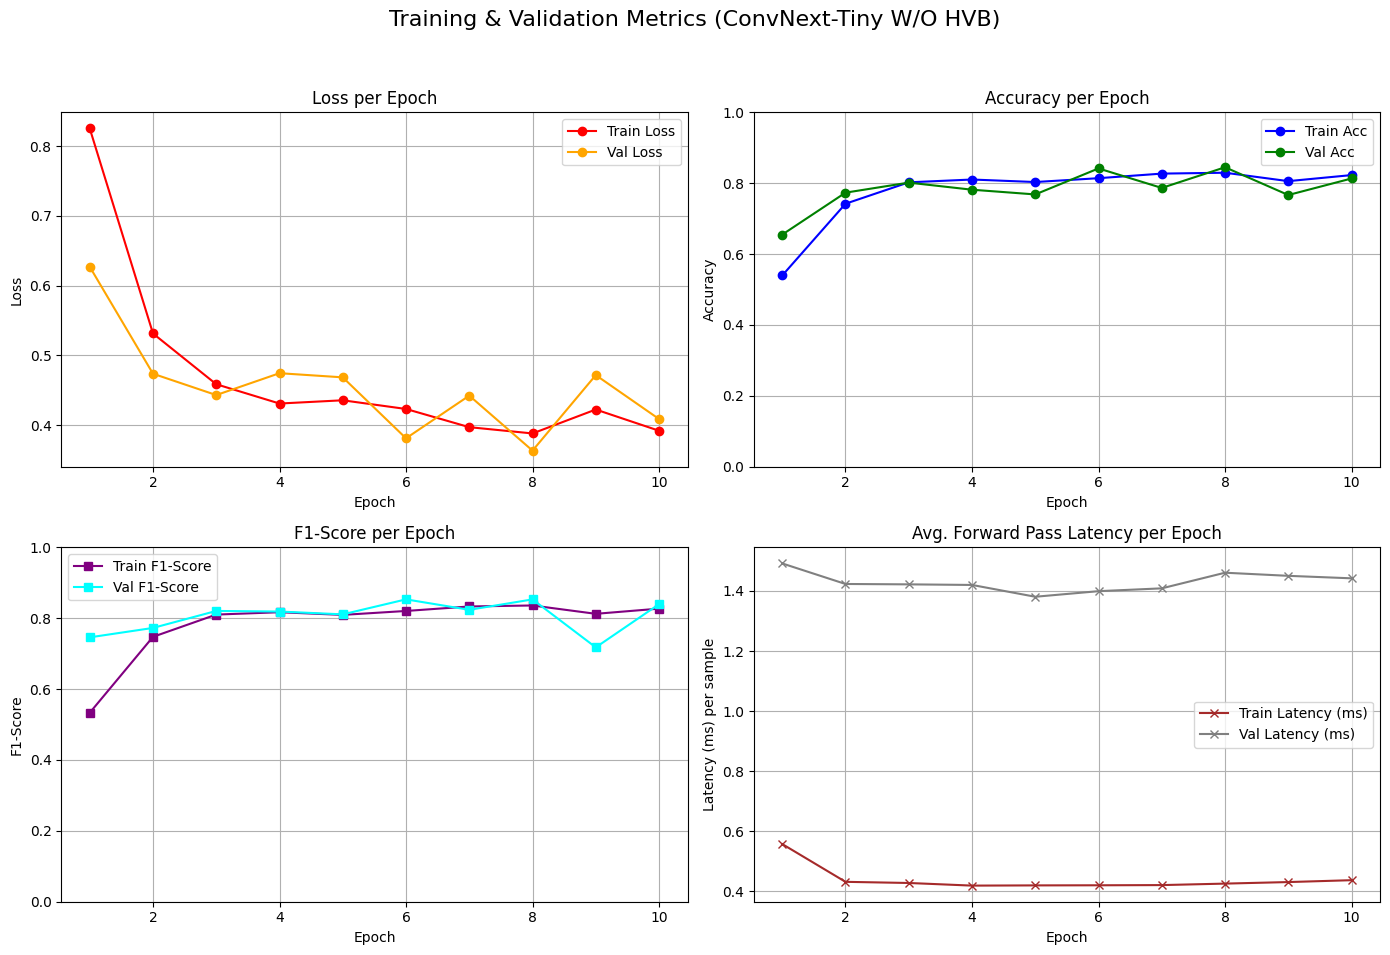

In [73]:
plot_training_history(history_convnext, "ConvNext-Tiny W/O HVB")

In [62]:
weights = models.ResNet50_Weights.DEFAULT
transform = weights.transforms()
model = RecognitionModel(models.resnet50(weights=weights))
train_df = pd.DataFrame(train_pairs, columns=("pic1", "pic2", "label"))
train_dataset = RecogDataset(df=train_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_df = pd.DataFrame(test_pairs, columns=("pic1", "pic2", "label"))
val_dataset = RecogDataset(df=val_df, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(model.fc1.parameters(), lr=0.1)
scheduler = ReduceLROnPlateau(optimizer, "min")
criterion = nn.BCELoss()
history_resnet = train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler, save_path="best_nose_model_resnet50.pth")

Epoch [1/10] | T Loss: 2.5867, T Acc: 0.5450, T F1: 0.5412 | V Loss: 1.1898, V Acc: 0.5683, V F1: 0.6046 | V Latency: 1.66 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_resnet50.pth (Val Acc: 0.5683)
Epoch [2/10] | T Loss: 1.0747, T Acc: 0.6529, T F1: 0.6507 | V Loss: 1.5434, V Acc: 0.5617, V F1: 0.6489 | V Latency: 1.58 ms/sample
Epoch [3/10] | T Loss: 1.2169, T Acc: 0.6475, T F1: 0.6478 | V Loss: 1.4295, V Acc: 0.5983, V F1: 0.5512 | V Latency: 1.64 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_resnet50.pth (Val Acc: 0.5983)
Epoch [4/10] | T Loss: 1.3591, T Acc: 0.6475, T F1: 0.6433 | V Loss: 1.3232, V Acc: 0.5767, V F1: 0.5822 | V Latency: 1.62 ms/sample
Epoch [5/10] | T Loss: 1.0639, T Acc: 0.6767, T F1: 0.6753 | V Loss: 1.2949, V Acc: 0.6167, V F1: 0.6217 | V Latency: 1.55 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_resnet50.pth (Val Acc: 0.6167)
Epoch [6/10] | T Loss: 1.0794, T Acc: 0.6804, T F1: 0.6803 | V Lo

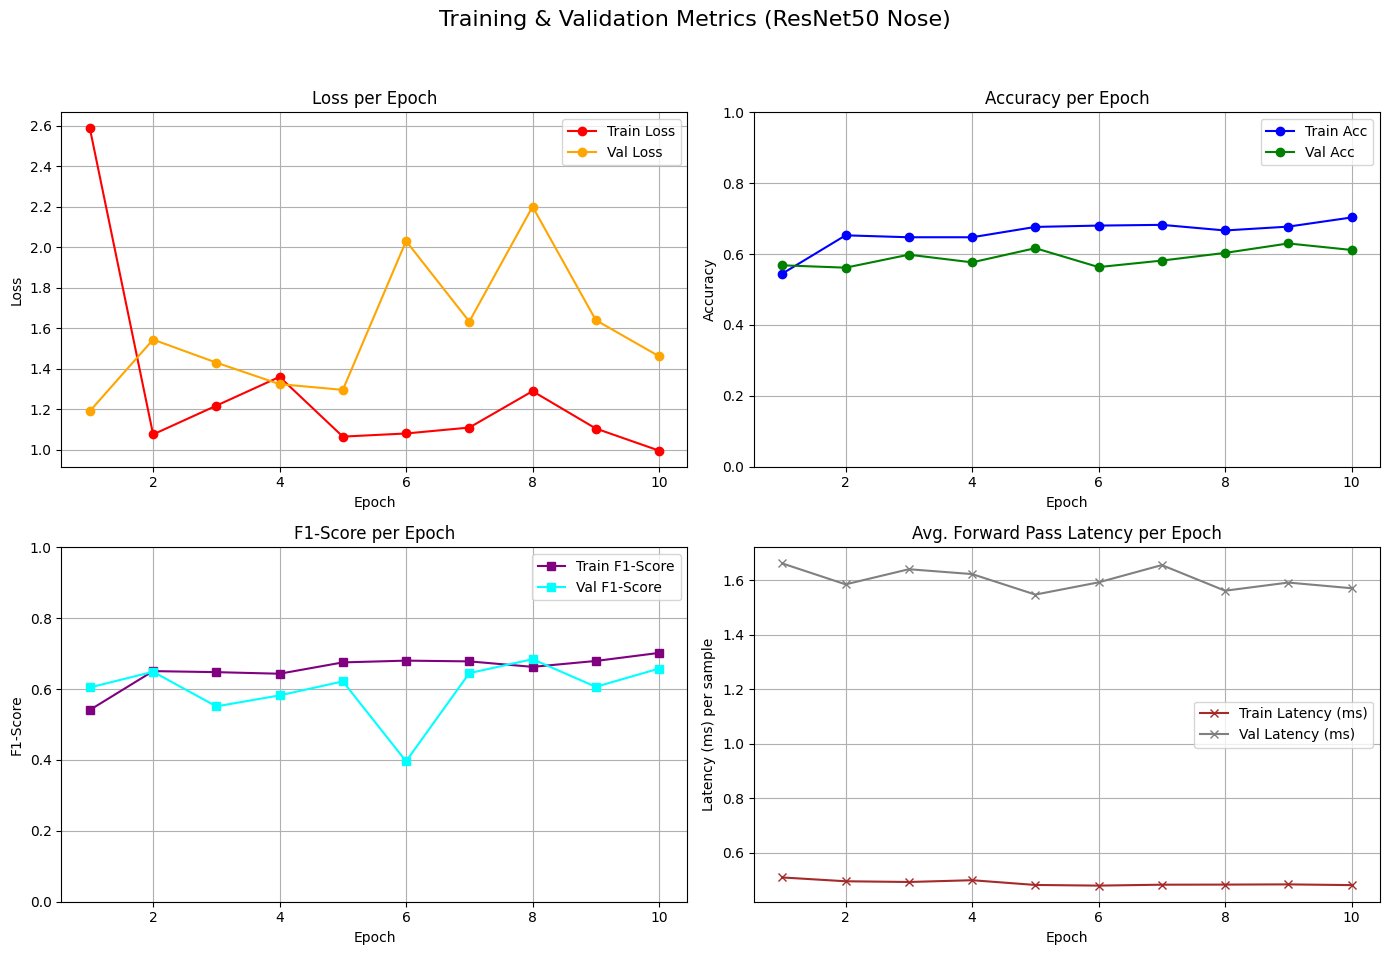

In [63]:
plot_training_history(history_resnet, "ResNet50 Nose")

In [56]:
weights = models.DenseNet121_Weights.DEFAULT
transform = weights.transforms()
model = RecognitionModel(models.densenet121(weights=weights))
train_df = pd.DataFrame(train_pairs, columns=("pic1", "pic2", "label"))
train_dataset = RecogDataset(df=train_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_df = pd.DataFrame(test_pairs, columns=("pic1", "pic2", "label"))
val_dataset = RecogDataset(df=val_df, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(model.fc1.parameters(), lr=0.1)
scheduler = ReduceLROnPlateau(optimizer, "min")
criterion = nn.BCELoss()
history_densenet = train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler, save_path="best_nose_model_densenet121.pth")

Epoch [1/10] | T Loss: 49.3430, T Acc: 0.4996, T F1: 0.6654 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.32 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_densenet121.pth (Val Acc: 0.5017)
Epoch [2/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.29 ms/sample
Epoch [3/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.40 ms/sample
Epoch [4/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.28 ms/sample
Epoch [5/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.31 ms/sample
Epoch [6/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F1: 0.6681 | V Latency: 4.31 ms/sample
Epoch [7/10] | T Loss: 49.8750, T Acc: 0.5012, T F1: 0.6678 | V Loss: 49.8333, V Acc: 0.5017, V F

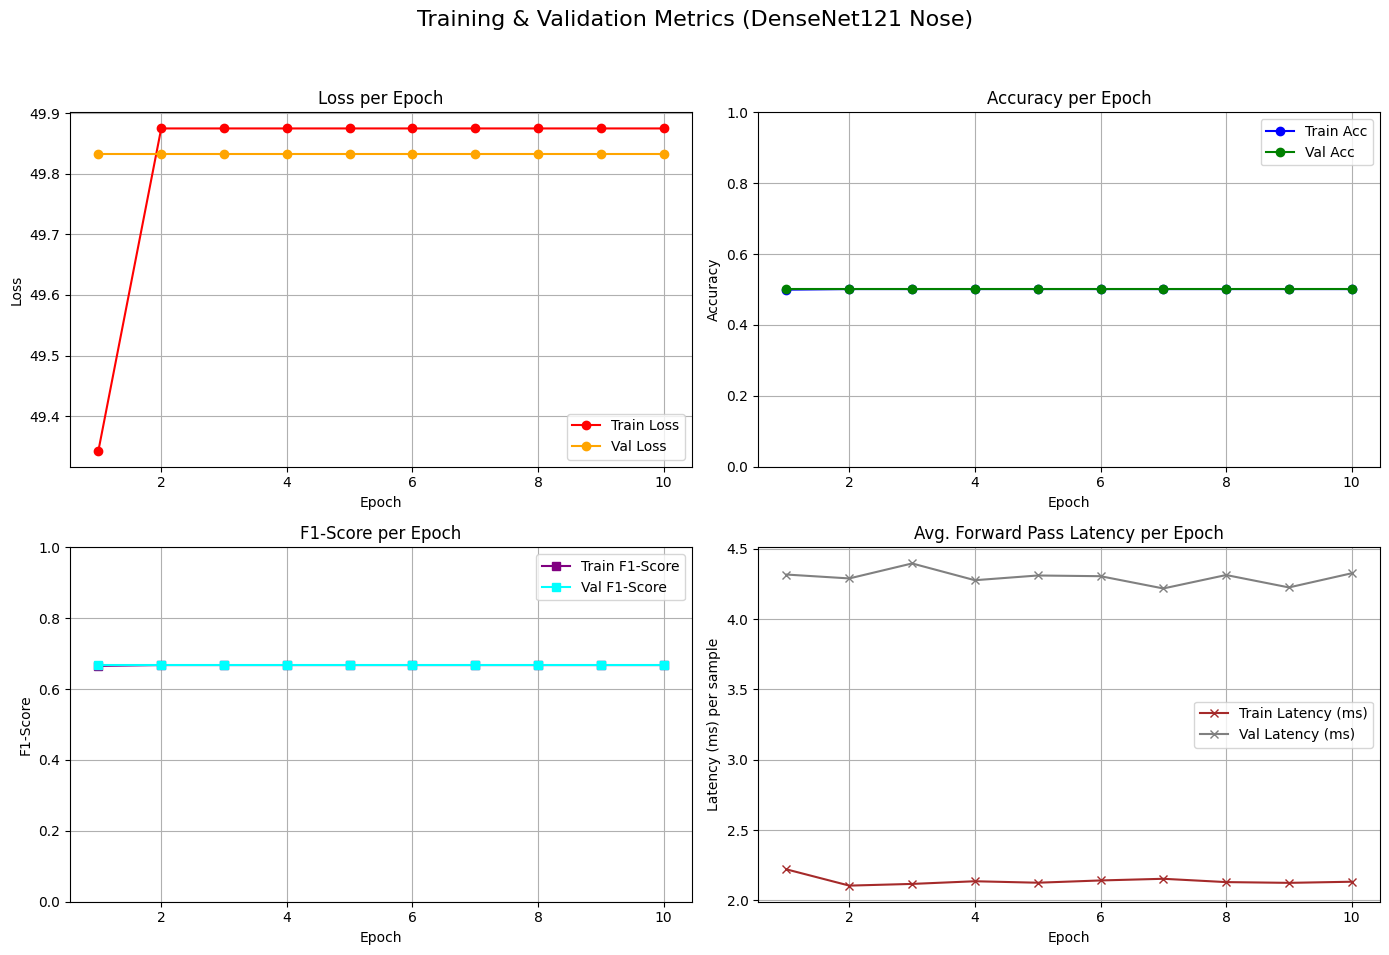

In [65]:
plot_training_history(history_densenet, "DenseNet121 Nose")

In [59]:
weights = models.EfficientNet_B4_Weights.DEFAULT
transform = weights.transforms()
model = RecognitionModel(models.efficientnet_b4(weights=weights))
train_df = pd.DataFrame(train_pairs, columns=("pic1", "pic2", "label"))
train_dataset = RecogDataset(df=train_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_df = pd.DataFrame(test_pairs, columns=("pic1", "pic2", "label"))
val_dataset = RecogDataset(df=val_df, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(model.fc1.parameters(), lr=0.1)
scheduler = ReduceLROnPlateau(optimizer, "min")
criterion = nn.BCELoss()
history_efficient = train_with_validation(model, train_loader, val_loader, optimizer, criterion, scheduler, save_path="best_nose_model_efficientnet.pth")

Epoch [1/10] | T Loss: 0.8949, T Acc: 0.5429, T F1: 0.5461 | V Loss: 0.6697, V Acc: 0.5967, V F1: 0.6219 | V Latency: 4.11 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_efficientnet.pth (Val Acc: 0.5967)
Epoch [2/10] | T Loss: 0.7533, T Acc: 0.5933, T F1: 0.5927 | V Loss: 0.6525, V Acc: 0.6183, V F1: 0.5783 | V Latency: 4.09 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_efficientnet.pth (Val Acc: 0.6183)
Epoch [3/10] | T Loss: 0.6681, T Acc: 0.6350, T F1: 0.6362 | V Loss: 0.7370, V Acc: 0.6100, V F1: 0.4293 | V Latency: 4.07 ms/sample
Epoch [4/10] | T Loss: 0.7206, T Acc: 0.6367, T F1: 0.6342 | V Loss: 0.6204, V Acc: 0.6550, V F1: 0.6336 | V Latency: 4.23 ms/sample
🎉 New best model saved to runs\recognition\best_nose_model_efficientnet.pth (Val Acc: 0.6550)
Epoch [5/10] | T Loss: 0.7238, T Acc: 0.6296, T F1: 0.6291 | V Loss: 0.6658, V Acc: 0.6367, V F1: 0.6677 | V Latency: 4.20 ms/sample
Epoch [6/10] | T Loss: 0.7254, T Acc: 0.6496, T F1: 0

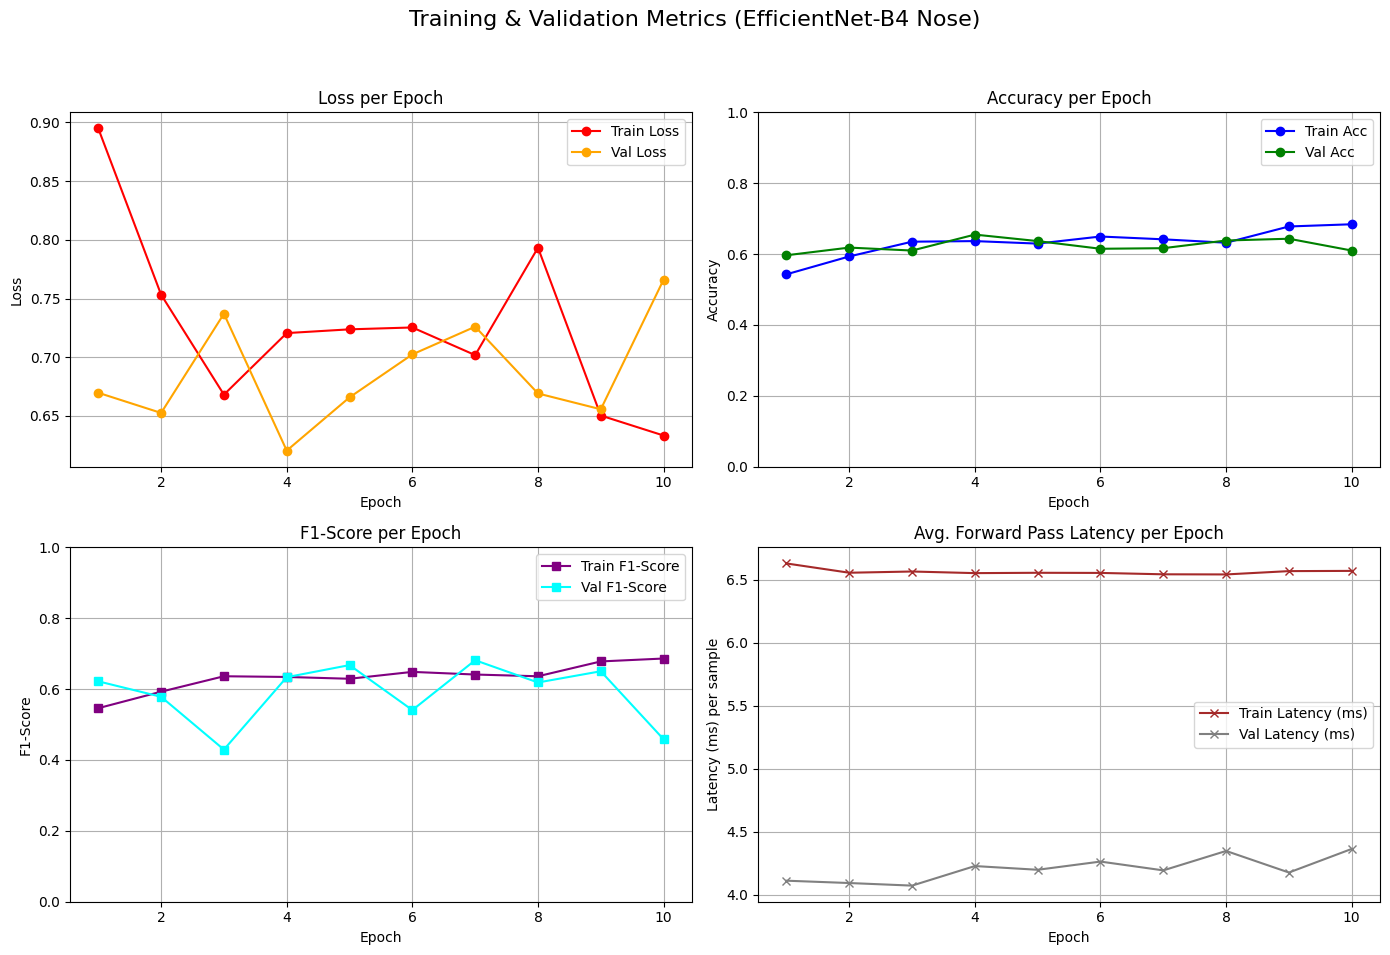

In [66]:
plot_training_history(history_efficient, "EfficientNet-B4 Nose")